<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-6---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Modulo_VI_Equipo_15_Habits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea Módulo VI - Aprendizaje No Supervisado**

**Metodologías:**

*   Principal Component Analysis (PCA)
*   t-Distributed Stochastic Neighbor Embedding (t-SNE)
*   Uniform Manifold Approximation and Projection (UMAP)

**PENDIENTES**

"Codificar categorías .. No One Hoted ... era ???

In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
#from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
#from sklearn.compose import ColumnTransformer
import umap
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# Como queremos una salida más limpia y legible de algunas gráficas importamos lo sig:
import warnings
warnings.filterwarnings("ignore")

# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Importar la información  ya limpia y normalizada
df_habits = pd.read_csv("habits - habits.csv", sep=',', encoding='utf-8')
print(df_habits.shape)
print(df_habits.head(3))
print(df_habits.info())

(1000, 15)
   age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0   23  Female                  0.0                 1.2            1.1   
1   20  Female                  6.9                 2.8            2.3   
2   21    Male                  1.4                 3.1            1.3   

  part_time_job  attendance_percentage  sleep_hours diet_quality  \
0            No                   85.0          8.0         Fair   
1            No                   97.3          4.6         Good   
2            No                   94.8          8.0         Poor   

   exercise_frequency parental_education_level internet_quality  \
0                   6                   Master          Average   
1                   6              High School          Average   
2                   1              High School             Poor   

   mental_health_rating extracurricular_participation  exam_score  
0                     8                           Yes        56.2  
1             

In [ ]:
#Podría haber diferentes decisiones:
# Opción 1: Considerar no utilizar parental_education_level
# Opción 2: Imputar parental_education_level
# Opción 2: Eliminar los 91 registros de lainformación (~10%)

df_habits.isnull().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


#PRIMERA SECCIÓN

## EDA

Análisis de las variables cuantitativas
1.   Descripción en tabla
2.   Visualización mediante gráficos de caja y bigotes e histogramas

Análisis de las variables cualitativas
1.   Elemento de lista
2.   Visualización mediante gráficos de barras




In [ ]:
# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64'])
cols_cuantitativas.describe().round(3)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,20.498,3.550,2.506,1.820,84.132,6.470,3.042,5.438,69.602
std,2.308,1.469,1.172,1.075,9.399,1.226,2.025,2.848,16.889
min,17.000,0.000,0.000,0.000,56.000,3.200,0.000,1.000,18.400
25%,18.750,2.600,1.700,1.000,78.000,5.600,1.000,3.000,58.475
50%,20.000,3.500,2.500,1.800,84.400,6.500,3.000,5.000,70.500
75%,23.000,4.500,3.300,2.525,91.025,7.300,5.000,8.000,81.325
max,24.000,8.300,7.200,5.400,100.000,10.000,6.000,10.000,100.000


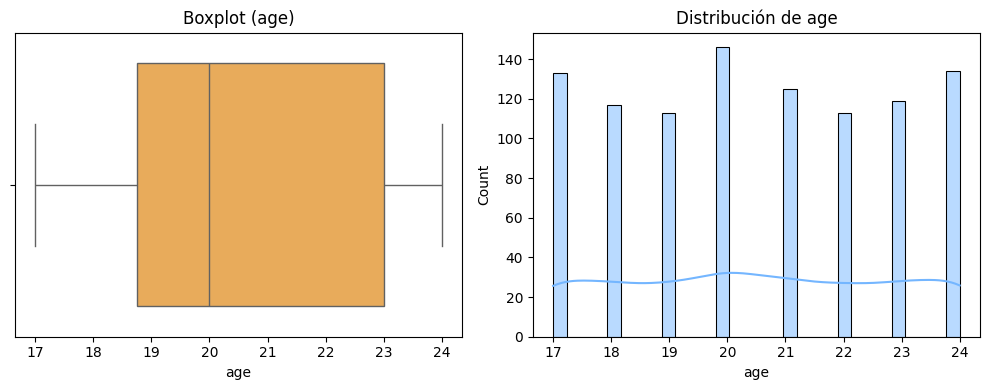

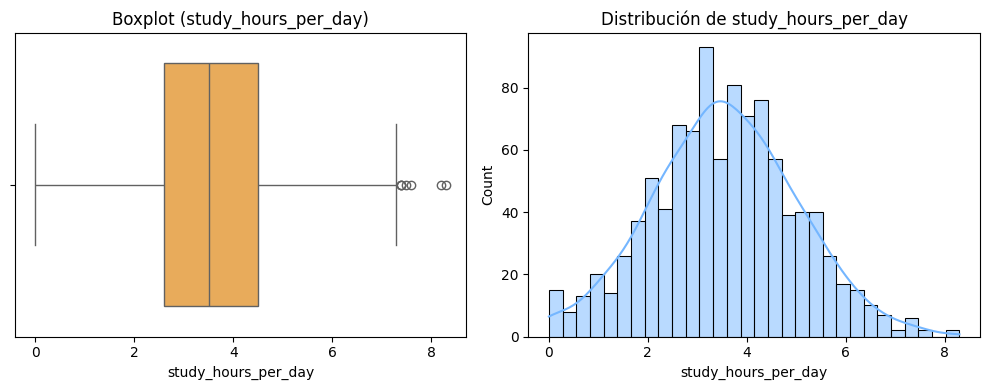

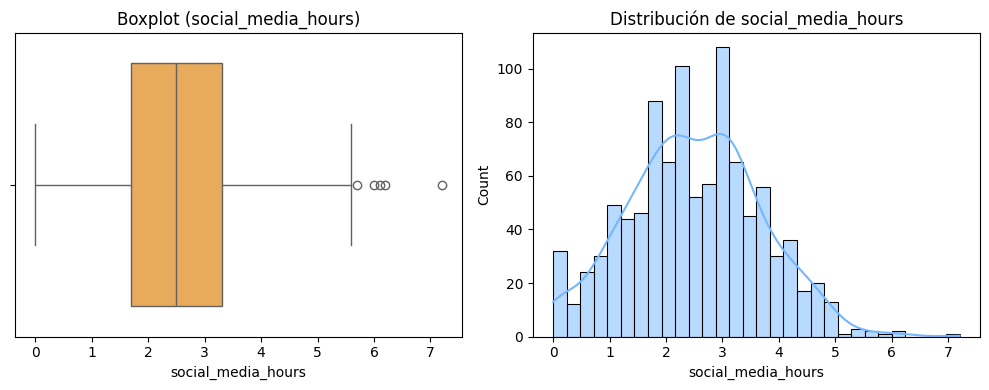

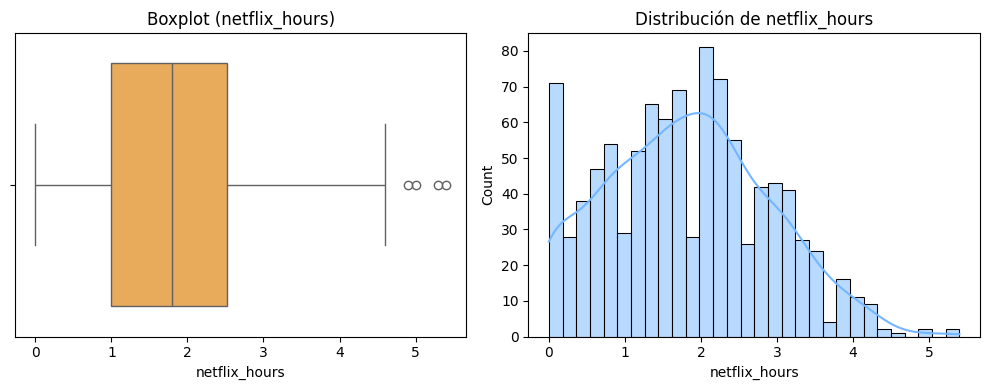

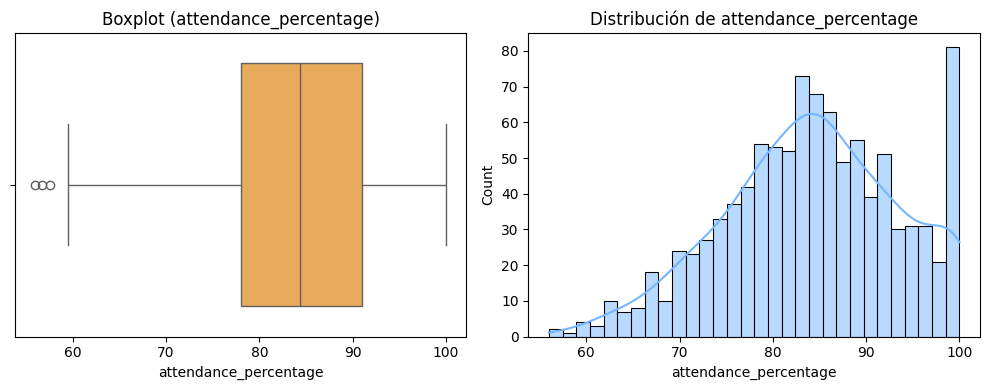

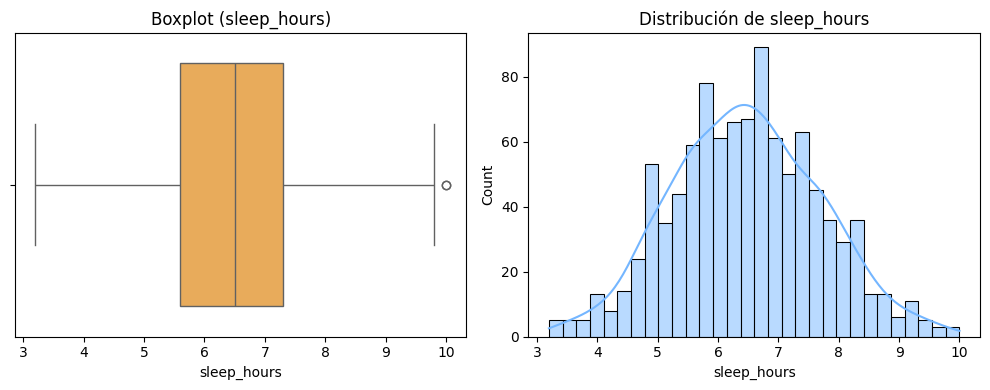

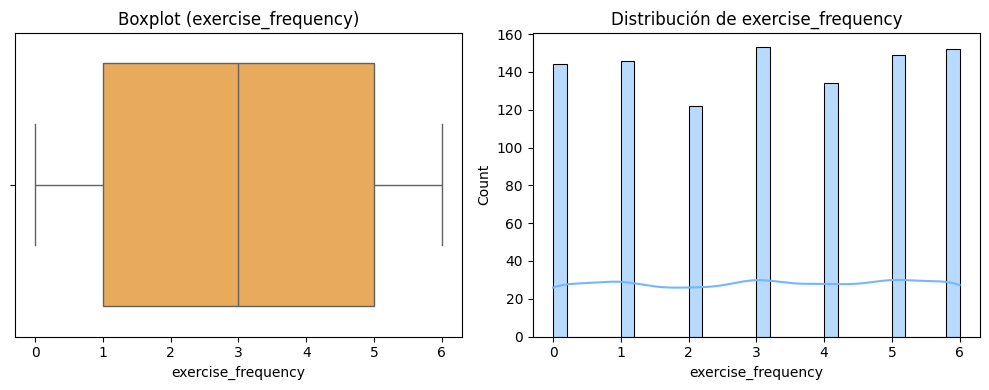

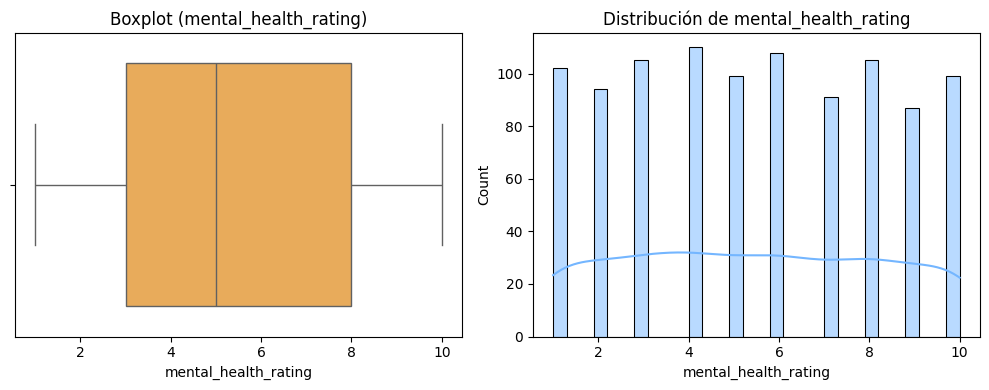

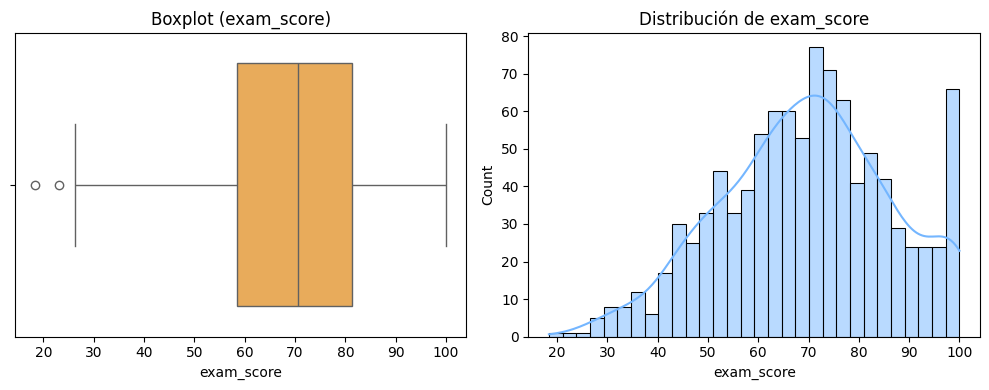

In [ ]:
# HISTOGRAMA Y GRAFICO  DE CAJA Y BIGOTES PARA VARIABLES CUANTITATIVA

# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64']).columns.tolist()
#cols_cuantitativas = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
#                      "attendande_percentage", "sleep_hours", "exercise_frequency", "mental_health_rating ",
#                      "exam_score"
#                      ]

# Iterar sobre cada columna y graficar
for col in cols_cuantitativas:
    plt.figure(figsize=(10, 4))  # tamaño de la figura

    #Gráfico de caja y bigotes
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_habits[col], color="#ffae44") #  palette="viridis"
    plt.title(f"Boxplot ({col})")

    # Gráfico para el histograma identificar sesgos o valores atípicos (outliers)
    plt.subplot(1, 2, 2)
    sns.histplot(df_habits[col], bins=30, color="#74b6ff", kde=True) #palette="viridis"
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

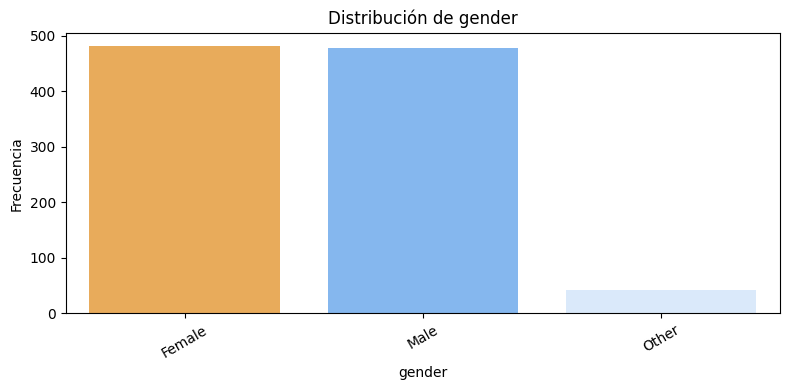

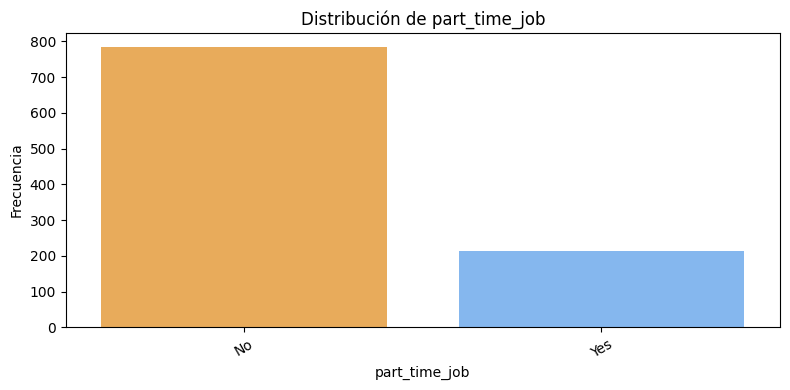

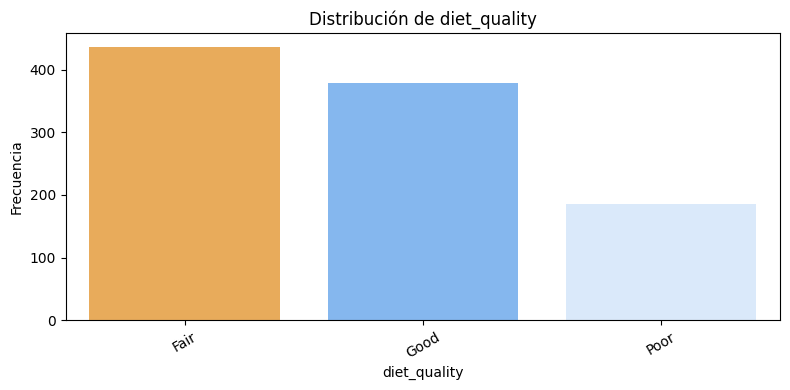

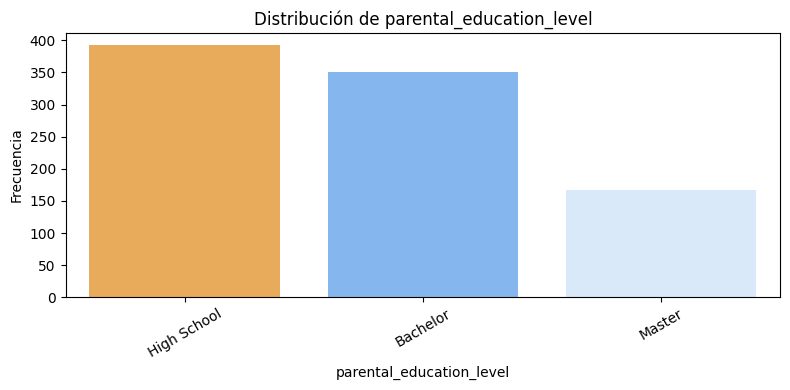

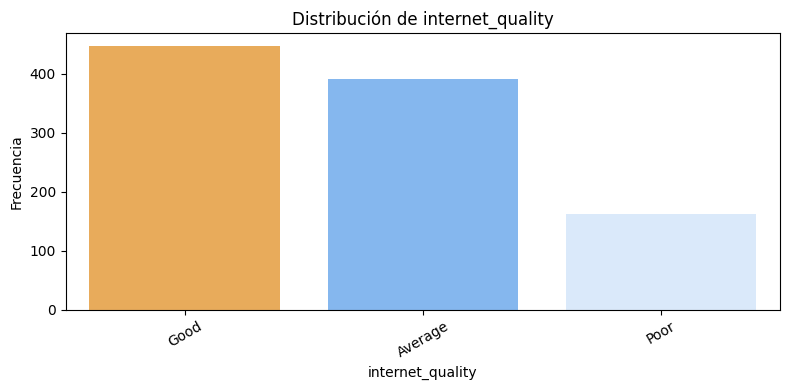

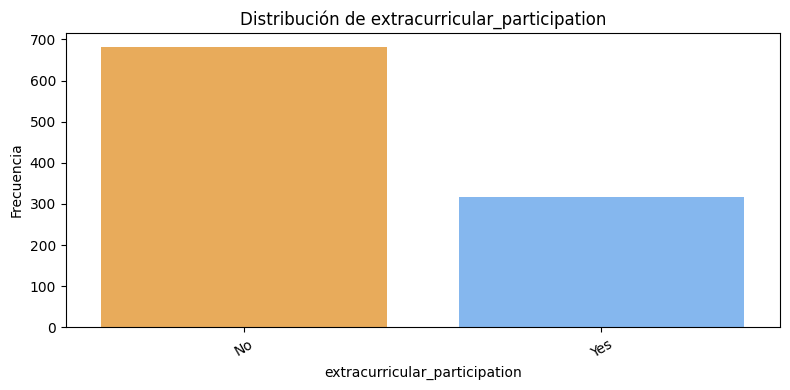

In [ ]:
# GRAFICO  DE BARRAS PARA VARIABLES CUALITATIVA

# Lista de columnas cuantitativas a analizar
cols_cualitativas = df_habits.select_dtypes(include=['object', 'category']).columns.tolist()

# Iterar sobre cada columna y graficar
for col in cols_cualitativas:
    plt.figure(figsize=(8, 4))

    # Conteo de categorías
    counts = df_habits[col].value_counts()

    # Gráfico de barras
    sns.barplot(x=counts.index, y=counts.values, palette=["#ffae44", "#74b6ff", "#d5e9ff"]) # "viridis"
    plt.title(f"Distribución de {col}")
    plt.ylabel("Frecuencia")
    plt.xlabel(col)
    plt.xticks(rotation=30)  # rotar etiquetas si son largas

    plt.tight_layout()
    plt.show()

# Preprocesamiento y Modelos de agrup...




In [ ]:
# Aqui observamos los datos unicos por columna.
cols = pd.Series(df_habits.columns)

for i in cols:
    print("Columna: ", i)
    display(df_habits[i].unique())
    print("\n")



Columna:  age


array([23, 20, 21, 19, 24, 18, 22, 17])



Columna:  gender


array(['Female', 'Male', 'Other'], dtype=object)



Columna:  study_hours_per_day


...

array([ 8,  1,  4, 10,  3,  9,  7,  5,  2,  6])



Columna:  extracurricular_participation


array(['Yes', 'No'], dtype=object)



Columna:  exam_score


array([ 56.2, 100. ,  34.3,  26.8,  66.4,  89.8,  72.6,  78.9,  63.3,
        74.4,  76.9,  75.8,  74. ,  55.2,  70.8,  43.9,  45.3,  58.5,
        82.5,  98.7,  43.7,  54.9,  69.9,  73.5,  71.1,  82.8,  75.7,
        70.6,  51.3,  52.1,  70.7,  51.2,  59.4,  58.1,  82.3,  69.7,
        66. ,  63.5,  65.7,  78.5,  75.1,  71. ,  59.7,  52.6,  96.5,
        62. ,  48.4,  68.1,  87.2,  66.7,  75.2,  46.4,  97.1,  61.2,
        75. ,  94.7,  77.6,  68.6,  69.6,  66.5,  62.2,  82.1,  55.1,
        77.1,  97.7,  66.9,  99.9,  57.2,  77.3,  91.6,  57.6,  60.2,
        50.5,  53.5,  79.2,  47.2,  73.4,  41.1,  77.8,  63.4,  70.2,
        81.3,  50.2,  87.9,  80.9,  63.9,  65.6,  93.2,  60.8,  50.4,
        74.3,  32.8,  60.4,  60. ,  77.5,  86.5,  83.3,  82.7,  94.8,
        80.8,  58.3,  66.3,  60.5,  84.8,  77. ,  61.7,  44. ,  42.4,
        88. ,  48.7,  81.6,  78.4,  67.6,  64.7,  64.1,  83.5,  96.2,
        65.4,  46.7,  75.5,  78.1,  85.2,  75.4,  64.2,  90.3,  81.4,
        65. ,  57.3,

## Preprocesameinto Manual

In [3]:
df_habits_proc = df_habits.copy()

# codifica las variables de manera manual
df_habits_proc['part_time_job'] = df_habits_proc['part_time_job'].map({'No': 0, 'Yes': 1})
df_habits_proc['diet_quality'] = df_habits_proc['diet_quality'].map({'Poor': -1, 'Fair': 0.1, 'Good': 1})
df_habits_proc['internet_quality'] = df_habits_proc['internet_quality'].map({'Poor': -1, 'Average': 0.1, 'Good': 1})
df_habits_proc['extracurricular_participation'] = df_habits_proc['extracurricular_participation'].map({'No': 0, 'Yes': 1})

# One-hot encoding para GENDER y P_educational_lvl.
df_habits_proc = pd.get_dummies(df_habits_proc, columns=["gender"], prefix="gender", dtype=int)
df_habits_proc = pd.get_dummies(df_habits_proc, columns=["parental_education_level"], prefix="p_edu_lvl", dtype=int)

df_habits_proc.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,internet_quality,mental_health_rating,extracurricular_participation,exam_score,gender_Female,gender_Male,gender_Other,p_edu_lvl_Bachelor,p_edu_lvl_High School,p_edu_lvl_Master
0,23,0.0,1.2,1.1,0,85.0,8.0,0.1,6,0.1,8,1,56.2,1,0,0,0,0,1
1,20,6.9,2.8,2.3,0,97.3,4.6,1.0,6,0.1,8,0,100.0,1,0,0,0,1,0
2,21,1.4,3.1,1.3,0,94.8,8.0,-1.0,1,-1.0,1,0,34.3,0,1,0,0,1,0
3,23,1.0,3.9,1.0,0,71.0,9.2,-1.0,4,1.0,1,1,26.8,1,0,0,0,0,1
4,19,5.0,4.4,0.5,0,90.9,4.9,0.1,3,1.0,1,0,66.4,1,0,0,0,0,1


In [ ]:
# Aqui observamos los datos unicos por columna.
cols_p = pd.Series(df_habits_proc.columns)

for i in cols_p:
    print("Columna: ", i)
    display(df_habits_proc[i].unique())
    print("\n")

Columna:  age


array([23, 20, 21, 19, 24, 18, 22, 17])



Columna:  study_hours_per_day


array([0. , 6.9, 1.4, 1. , 5. , 7.2, 5.6, 4.3, 4.4, 4.8, 4.6, 3.9, 3.7,
       3.4, 2.4, 3.1, 2. , 1.8, 3.8, 4.9, 1.1, 3.2, 1.5, 2.6, 4. , 4.2,
       3.5, 5.5, 2.9, 3.6, 2.5, 6.1, 1.6, 5.4, 2.2, 6.7, 1.7, 4.5, 4.1,
       3.3, 6.8, 2.7, 7.4, 2.3, 6. , 5.9, 1.2, 0.5, 5.3, 2.1, 5.1, 1.9,
       3. , 7. , 0.7, 0.3, 4.7, 5.8, 5.7, 1.3, 0.8, 2.8, 6.2, 6.5, 0.6,
       6.6, 0.9, 7.3, 6.3, 5.2, 8.3, 6.4, 0.2, 7.5, 8.2, 7.6, 0.1, 7.1])



Columna:  social_media_hours


...

array([0, 1])



Columna:  p_edu_lvl_High School


array([0, 1])



Columna:  p_edu_lvl_Master


array([1, 0])

In [4]:
# Expotar .csv
df_habits_proc.to_csv("df_habits_processed.csv", sep='\t', encoding='utf-8', index=False, header=True)

In [5]:
# Eliminando valores missing
df_habits_proc_nomiss = df_habits_proc.dropna()
print(df_habits_proc_nomiss)

     age  study_hours_per_day  social_media_hours  netflix_hours  \
0     23                  0.0                 1.2            1.1   
1     20                  6.9                 2.8            2.3   
2     21                  1.4                 3.1            1.3   
3     23                  1.0                 3.9            1.0   
4     19                  5.0                 4.4            0.5   
..   ...                  ...                 ...            ...   
995   21                  2.6                 0.5            1.6   
996   17                  2.9                 1.0            2.4   
997   20                  3.0                 2.6            1.3   
998   24                  5.4                 4.1            1.1   
999   19                  4.3                 2.9            1.9   

     part_time_job  attendance_percentage  sleep_hours  diet_quality  \
0                0                   85.0          8.0           0.1   
1                0                   97

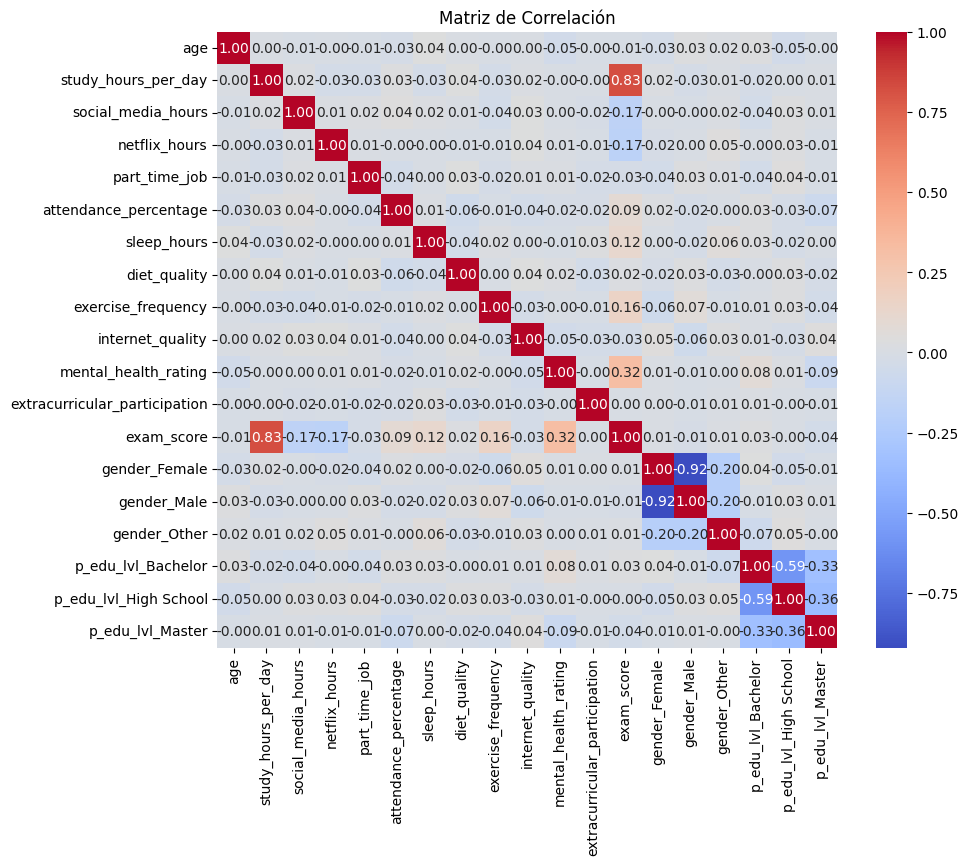

In [ ]:
# Correlación de las variables
# DUDA! ¿No se tiene que cambiar el tipo de correlación dependiendo del tipo de variable? *Programación al final que selecciona por tipo de variable
corr_matrix = df_habits_proc_nomiss.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()


study_hours_per_day              0.83
mental_health_rating             0.32
exercise_frequency               0.16
sleep_hours                      0.12
attendance_percentage            0.09
p_edu_lvl_Bachelor               0.03
diet_quality                     0.02
gender_Other                     0.01
gender_Female                    0.01
extracurricular_participation    0.00
p_edu_lvl_High School           -0.00
age                             -0.01
gender_Male                     -0.01
part_time_job                   -0.03
internet_quality                -0.03
p_edu_lvl_Master                -0.04
social_media_hours              -0.17
netflix_hours                   -0.17
Name: exam_score, dtype: float64


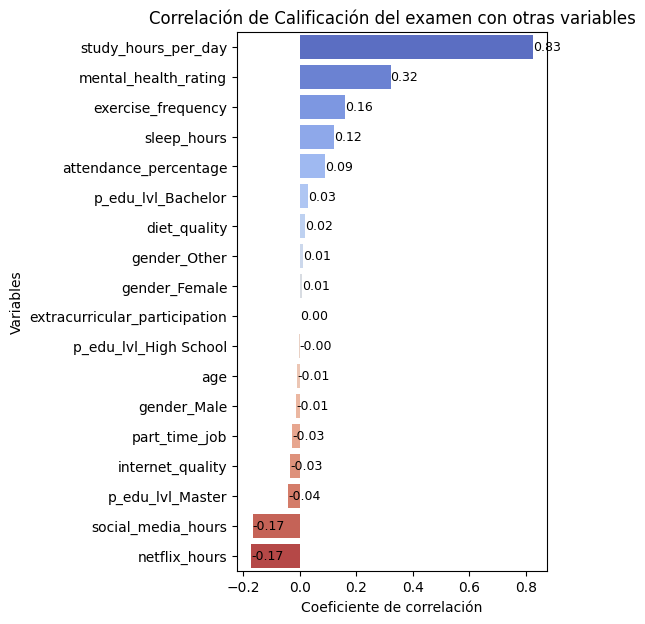

In [ ]:
#Correlación de la calificación del examen con el resto
#Programación autocontenida

# 2. Calcular la matriz de correlación
corr_matrix = df_habits_proc_nomiss.corr()

# 2. Extraer solo la correlación con PM25
corr_exscr = corr_matrix["exam_score"].drop("exam_score")  # quitamos la correlación consigo misma

# 3. Ordenar las correlaciones de mayor a menor
corr_exscr_sorted = corr_exscr_sorted.sort_values(ascending=False)

# 4. Mostrar resultados
print(corr_exscr_sorted.round(2))

# 5. Graficar como barra horizontal
plt.figure(figsize=(4, 7))
sns.barplot(x=corr_exscr_sorted.values, y=corr_exscr_sorted.index, palette="coolwarm")
# Añadir los valores numéricos en cada barra
for i, v in enumerate(corr_exscr_sorted.values):
    plt.text(v, i, f"{v:.2f}", color='black', va='center', ha='left', fontsize=9)

plt.title("Correlación de Calificación del examen con otras variables")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.show()

# PCA

Reducción lineal de dimensión y análisis de varianza

Varianza explicada: Componente 1: 77.09%, Componente 2: 7.10%
Total de información retenida en 2D: 84.19%


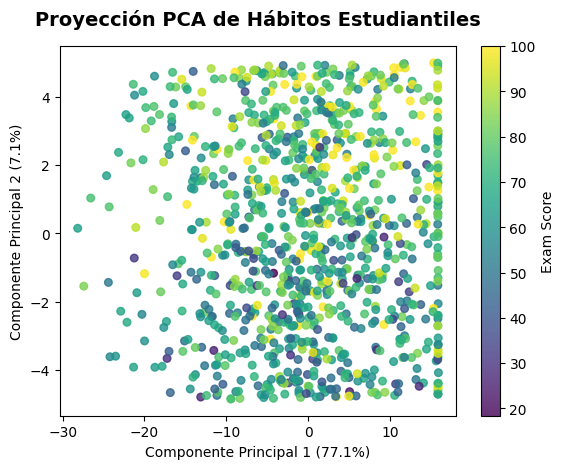

Componentes principales:
 [[-6.78247988e-03  4.20691420e-03  5.13085504e-03 -2.46181127e-04
  -1.83085025e-03  9.99907534e-01  1.81891114e-03 -4.37439837e-03
  -1.78131851e-03 -3.17404509e-03 -6.22034448e-03 -8.81402451e-04
   1.31826620e-03 -1.29283410e-03 -2.54320973e-05  1.65960463e-03
  -1.37385087e-03 -2.87616456e-03]
 [-1.05941839e-01 -2.54672619e-03  1.37115929e-03  3.49464334e-03
   2.01308979e-03  5.41147567e-03 -4.94730269e-03  5.65686456e-03
   1.13654481e-04 -1.25183719e-02  9.94080746e-01 -7.67315412e-04
   1.50435849e-03 -1.58510775e-03  8.07492654e-05  1.26939390e-02
   2.46109484e-03 -1.18372405e-02]]


In [ ]:
X = df_habits_proc_nomiss.drop(columns=['exam_score'])
pca = PCA(n_components=2, random_state=42) # combinación lineal de n variables originales que maximiza la varianza. y se fija la semilla
X_pca = pca.fit_transform(X)

var_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada: Componente 1: {var_explicada[0]*100:.2f}%, Componente 2: {var_explicada[1]*100:.2f}%")
print(f"Total de información retenida en 2D: {(var_explicada[0] + var_explicada[1])*100:.2f}%")

plt.scatter(X_pca[:,0], X_pca[:,1], c=df_habits_proc_nomiss['exam_score'], cmap='viridis', alpha=0.8, s=30 ) # alpha trasluce los colores
plt.title('Proyección PCA de Hábitos Estudiantiles', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}%)')
plt.colorbar(label="Exam Score")
plt.show()

print("Componentes principales:\n", pca.components_)

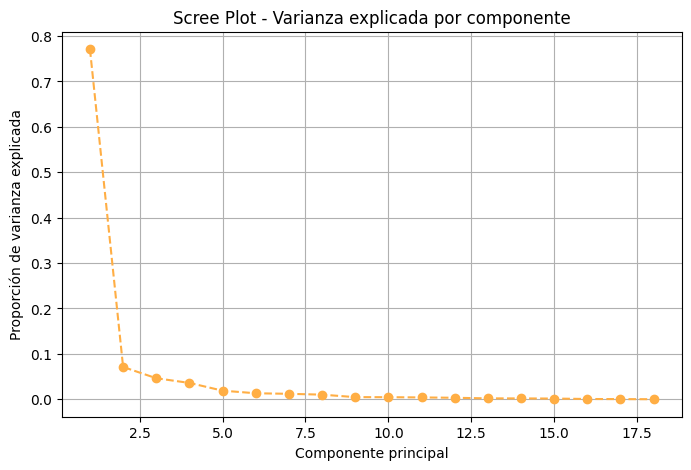

In [ ]:
# Definir PCA con todos los componentes
#Este gráfico permite decidir cuántos componentes usar (ej. los que explican más del 70–80% de la varianza acumulada).

pca_full = PCA()
pca_full.fit(X)

# Varianza explicada por cada componente
explained_var = pca_full.explained_variance_ratio_

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='--',color = "#ffae44" )
plt.title("Scree Plot - Varianza explicada por componente")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.grid(True)
plt.show()

In [ ]:
# Matriz de cargas (componentes)
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_full.components_))],
    index=X.columns
)

print("Matriz de cargas de variables en cada componente:")
print(loadings.round(3))

Matriz de cargas de variables en cada componente:
                                 PC1    PC2    PC3    PC4    PC5    PC6  \
age                           -0.007 -0.106  0.994  0.013 -0.002 -0.026   
study_hours_per_day            0.004 -0.003  0.004 -0.045  0.994  0.065   
social_media_hours             0.005  0.001 -0.005 -0.033  0.034  0.212   
netflix_hours                 -0.000  0.003 -0.000 -0.004 -0.049 -0.002   
part_time_job                 -0.002  0.002 -0.002 -0.005 -0.009  0.002   
attendance_percentage          1.000  0.005  0.007  0.002 -0.004 -0.003   
sleep_hours                    0.002 -0.005  0.027  0.020 -0.073  0.974   
diet_quality                  -0.004  0.006  0.002  0.000  0.027 -0.025   
exercise_frequency            -0.002  0.000 -0.014  0.998  0.047 -0.008   
internet_quality              -0.003 -0.013 -0.001 -0.015  0.009  0.010   
mental_health_rating          -0.006  0.994  0.106  0.001  0.002  0.002   
extracurricular_participation -0.001 -0.001 -0.001

Dadas las correlaciones, estoy interesada en revisar la variabilidad de otros PC's
- Study_hours_per_day 0.83 - PC5
- Mental_health_rating 0.32 - PC2
- Exercise_frequency 0.16 - PC4
- Social_media -0.17 - PC7
- Netflix -0.17 - PC8

In [ ]:
# Comprueba que los PCA de las dos programaciones son la misma
# PCA con 2 componentes
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X)

# PCA con todos los componentes
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X)

# Comparar PC1 y PC2
print("PC1 iguales:", np.allclose(pca_2.components_[0], pca_full.components_[0]))
print("PC2 iguales:", np.allclose(pca_2.components_[1], pca_full.components_[1]))

PC1 iguales: True
PC2 iguales: True


# t-SNE

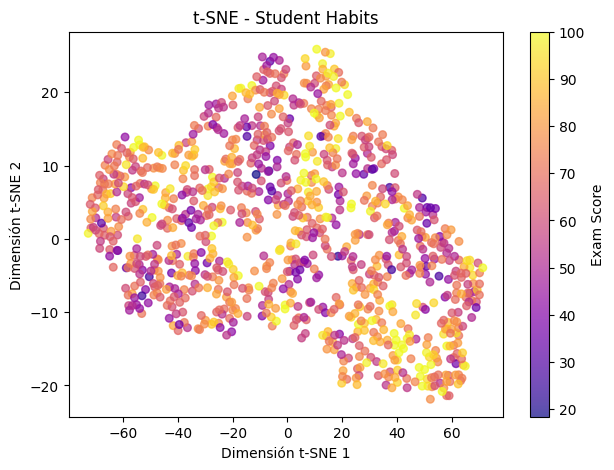

In [12]:
# Nota: La 'perplexity' (perplejidad) es clave aquí.
# Controla cuántos "vecinos" considera el algoritmo.

X = df_habits_proc_nomiss.drop(columns=['exam_score'])
tsne = TSNE(
    n_components=2, # número de dimensiones de salida
    perplexity=30,  # tamaño del vecindar(io considerado, (ej. 10, 20, 40).
    learning_rate=200,  # velocidad de ajuste, (entre 100 y 1000; 200 es un buen inicio.)
    n_iter=3000, # número de iteraciones  (3000–5000 para mayor estabilidad.)
    random_state=42) # semilla para reproducibilidad

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df_habits_proc_nomiss['exam_score'], cmap='plasma', alpha=0.7, s=30)
plt.title("t-SNE - Student Habits")
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.colorbar(label="Exam Score")
plt.show()

Se "empieza" a ver un grupo en la parte inferior con perplexity=15

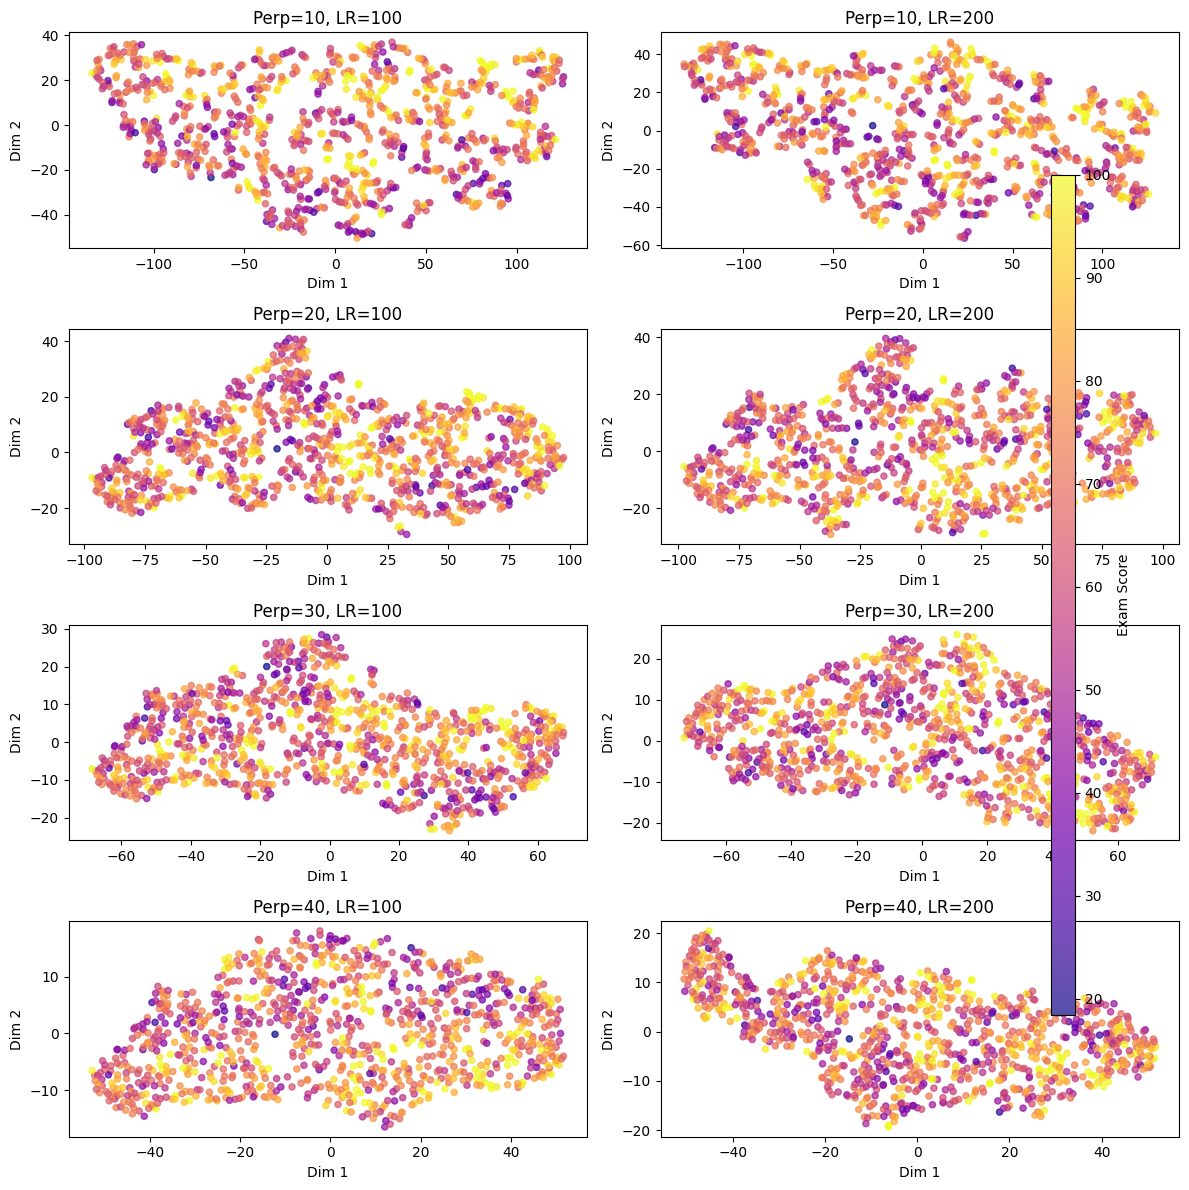

In [14]:
X = df_habits_proc_nomiss.drop(columns=['exam_score'])

# Valores a probar
perplexities = [10, 20, 30, 40]
learning_rates = [100, 200]

# Crear figura con subplots
fig, axes = plt.subplots(len(perplexities), len(learning_rates), figsize=(12, 12))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(learning_rates):
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            learning_rate=lr,
            n_iter=3000,
            random_state=42
        )
        X_tsne = tsne.fit_transform(X)

        ax = axes[i, j]
        scatter = ax.scatter(
            X_tsne[:,0], X_tsne[:,1],
            c=df_habits_proc_nomiss['exam_score'],
            cmap='plasma', alpha=0.7, s=20
        )
        ax.set_title(f"Perp={perp}, LR={lr}")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

# Barra de colores compartida
# Ajustar espacio para la barra de colores
fig.subplots_adjust(right=0.85)  # deja espacio a la derecha
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # posición [x, y, ancho, alto]
fig.colorbar(scatter, cax=cbar_ax, label="Exam Score")


plt.tight_layout()
plt.show()

# UMAP

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)
plt.scatter(X_umap[:,0], X_umap[:,1], c=df['exam_score'], cmap='coolwarm')
plt.title("UMAP - Student Habits")
plt.colorbar(label="Exam Score")
plt.show()

In [ ]:
# UMAP sin especificar hiper-parámetros (valores por defecto)

# tomamos las variables numericas
numeric_cols = habits_nomiss.select_dtypes(include=[np.number]).columns
# print(numeric_cols)
Scaled_habits_data = StandardScaler().fit_transform(habits_nomiss[numeric_cols])
# print(type(Scaled_habits_data), Scaled_habits_data.shape)

reducer = umap.UMAP(random_state=42) # con semilla, para que no mueva los resultados
df_umap = reducer.fit_transform(Scaled_habits_data)
# Resultados
print(type(df_umap), df_umap.shape)
print(df_umap[:5])

# # Version pingüinos
# plt.scatter(
#     df_umap[:, 0],
#     df_umap[:, 1],
#     c=[sns.color_palette()[x] for x in habits_nomiss[["age"]]])
# plt.gca().set_aspect('equal', 'datalim')
# plt.title('UMAP projection of the Penguin dataset', fontsize=24);

<class 'numpy.ndarray'> (909, 2)
[[10.216055   5.778007 ]
 [ 4.44742    4.939366 ]
 [10.067235   4.0047736]
 [10.17219    4.918353 ]
 [ 8.200964   3.097814 ]]


In [ ]:
# Para que podamos tomar la variable de "Calificaciones" la segmentamos en quartiles:
habits_nomiss["exam_quartile"] = pd.qcut(
    habits_nomiss["exam_score"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

bins = [0, 3, 5.9, 8, 10]   # límites de los intervalos
labels = ["0-3", "3-5.9", "6-8", "8-10"]

# Verificar resultado
print(habits_nomiss[["exam_score", "exam_quartile"]].head())

   exam_score exam_quartile
0        56.2            Q1
1       100.0            Q4
2        34.3            Q1
3        26.8            Q1
4        66.4            Q2


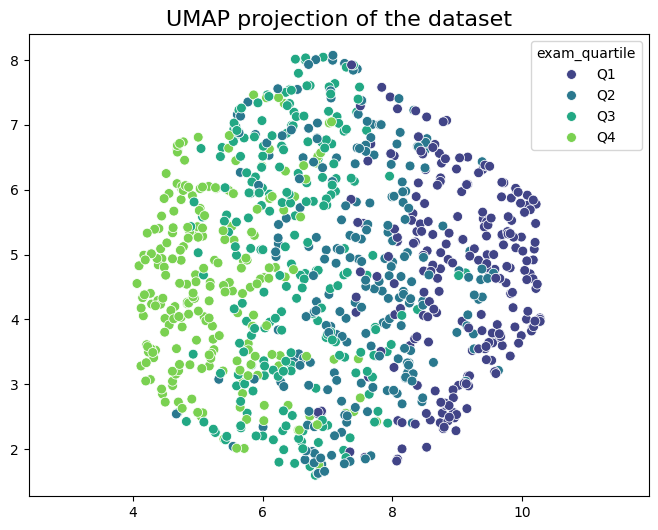

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_umap[:, 0],
    y=df_umap[:, 1],
    hue=habits_nomiss["exam_quartile"],   # aquí pasas la variable
    palette="viridis",          # paleta de colores
    s=50                        # tamaño de los puntos
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the dataset', fontsize=16)
plt.legend(title="exam_quartile")
plt.show()

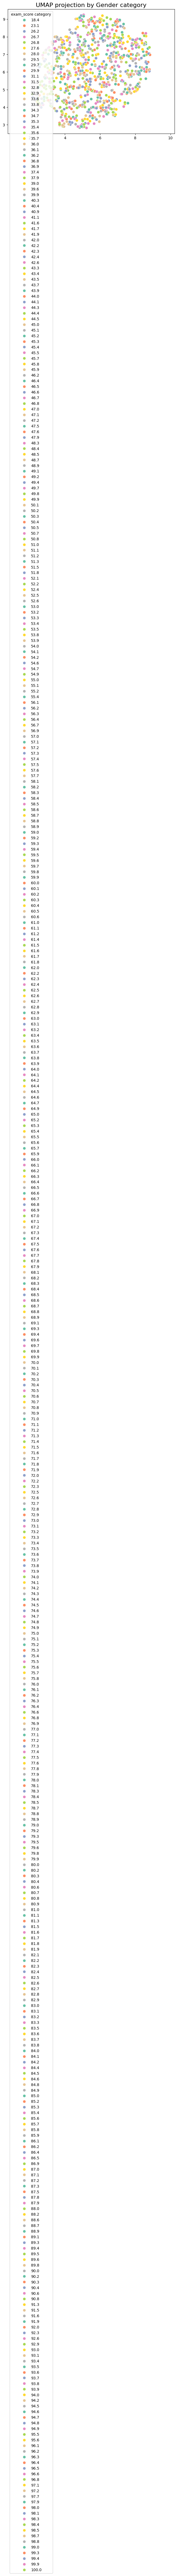

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_umap[:, 0],
    y=df_umap[:, 1],
    hue=habits_nomiss["exam_score"],   # variable categórica
    palette="Set2",             # paleta discreta (Set1, Set2, Paired, etc.)
    s=60
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection by exam_score category', fontsize=16)
plt.legend(title="exam_score category")
plt.show()

In [ ]:
habits_nomiss[["gender"]]
#  ({"Female":0,"Male":1,"Other":2})

,gender
0,Female
1,Female
2,Male
3,Female
4,Female
...,...
995,Female
996,Female
997,Male
998,Male


# Preprocesamiento Pipelines

In [ ]:
exam_scores = df_habits['exam_score'].copy()

X = df_habits.drop(columns=['exam_score'])

# esto es mejor que el one-hot, dado que mantenemos más baja la dimensionalidad
X['part_time_job'] = X['part_time_job'].map({'No': 0, 'Yes': 1})
X['extracurricular_participation'] = X['extracurricular_participation'].map({'No': 0, 'Yes': 1})

diet_categories = ['Poor', 'Fair', 'Good']
internet_categories = ['Poor', 'Average', 'Good']
# Observamos la columna parental_education_level es la única con NaN.
# Cambiamos NaN a string "Unknown"
education_categories = ['High School', 'Bachelor', 'Master', "Unknown"]

col_education = ['parental_education_level']
cols_other_ordinal = ['diet_quality', 'internet_quality']
cols_nominal = ['gender']
cols_numeric = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
                'attendance_percentage', 'sleep_hours', 'exercise_frequency',
                'mental_health_rating', 'part_time_job', 'extracurricular_participation']

education_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ordinal', OrdinalEncoder(categories=[education_categories]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_numeric),
        ('edu_ord', education_pipeline, col_education), # Usamos education_pipline
        ('other_ord', OrdinalEncoder(categories=[diet_categories, internet_categories]), cols_other_ordinal),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), cols_nominal)
    ],
    remainder='passthrough'
)

pipeline_final = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('scaler_final', StandardScaler())
])

X_procesado_array = pipeline_final.fit_transform(X)

In [ ]:
# Esto es simplemente para ver el dataframe trasformado, por si nos es útil para el reporte
# ya que los piplines lo convierte a arranges abstractos sin nombres.

nombres_columnas = pipeline_final.named_steps['preprocess'].get_feature_names_out()
df_procesado = pd.DataFrame(X_procesado_array, columns=nombres_columnas)

display(df_procesado.head())

,num__age,num__study_hours_per_day,num__social_media_hours,num__netflix_hours,num__attendance_percentage,num__sleep_hours,num__exercise_frequency,num__mental_health_rating,num__part_time_job,num__extracurricular_participation,edu_ord__parental_education_level,other_ord__diet_quality,other_ord__internet_quality,nom__gender_Male,nom__gender_Other
0,1.084551,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,-0.523341,1.464464,1.086723,-0.266175,-0.392302,-0.955011,-0.209383
1,-0.215870,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,-0.523341,-0.682844,-0.997118,1.112970,-0.392302,-0.955011,-0.209383
2,0.217604,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,-0.523341,-0.682844,-0.997118,-1.645320,-1.768800,1.047108,-0.209383
3,1.084551,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,-0.523341,1.464464,1.086723,-1.645320,0.984196,-0.955011,-0.209383
4,-0.649344,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,-0.523341,-0.682844,1.086723,-0.266175,0.984196,-0.955011,-0.209383


Detecta automáticamente si la variable es binaria, categórica o continua.

Aplica el método correcto:

Point-Biserial → binaria vs continua.

Spearman → categórica vs continua.

Pearson → continua vs continua.

Devuelve un DataFrame resumen con:

Tipo de variable

Método usado

Coeficiente de correlación (2 decimales)

p-valor (cuando aplica)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr, spearmanr, chi2_contingency

def auto_correlations(df, target="exam_score"):
    resultados = {}

    for col in df.columns:
        if col == target:
            continue  # saltar la variable objetivo

        # Detectar tipo de variable
        unique_vals = df[col].dropna().unique()
        n_unique = len(unique_vals)

        # Caso 1: Binaria (0/1 o True/False)
        if n_unique == 2:
            corr, pval = pointbiserialr(df[col], df[target])
            resultados[col] = {"tipo":"binaria vs continua",
                               "metodo":"point-biserial",
                               "corr":round(corr,2),
                               "pval":round(pval,4)}

        # Caso 2: Categórica con más de 2 niveles
        elif df[col].dtype == "object" or n_unique < 10:
            # Usamos Spearman como aproximación
            corr, pval = spearmanr(df[col].astype("category").cat.codes, df[target])
            resultados[col] = {"tipo":"categórica vs continua",
                               "metodo":"spearman",
                               "corr":round(corr,2),
                               "pval":round(pval,4)}

        # Caso 3: Continua
        else:
            corr = df[col].corr(df[target])  # Pearson por defecto
            resultados[col] = {"tipo":"continua vs continua",
                               "metodo":"pearson",
                               "corr":round(corr,2),
                               "pval":None}

    return pd.DataFrame(resultados).T

# Ejemplo de uso
resultados_corr = auto_correlations(df_habits_proc_nomiss, target="exam_score")
print(resultados_corr)